In [1]:
import pandas as pd
import glob
import os

# 1. Localizar los archivos
path = "/home/lsilva/Github/ADST_Alexey_module_v8/parquet_qgs_helio_17/"
all_files = sorted(glob.glob(os.path.join(path, "*.parquet")))

if not all_files:
    print("❌ No se encontraron archivos Parquet en la ruta.")
else:
    # Cargamos solo el primer archivo para no saturar la RAM
    file_to_test = all_files[0]
    df = pd.read_parquet(file_to_test)

    print(f"📊 Reporte de Salud: {os.path.basename(file_to_test)}")
    print(f"📏 Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
    print(f"💾 Uso de Memoria: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    print("-" * 50)

    # 2. Análisis de Completitud (NaNs)
    # Mostramos cuántos datos reales (no nulos) hay en cada columna
    reporte = pd.DataFrame({
        'Datos_Presentes': df.count(),
        'NaNs': df.isnull().sum(),
        '%_Completitud': (df.count() / len(df) * 100).round(2)
    })
    
    print("📋 Estado de las Columnas:")
    print(reporte)
    
    print("-" * 50)
    # 3. Vista previa de los valores clave
    print("🔍 Muestra de datos (Primeras 5 estaciones con UMD):")
    cols_interes = ['event_id', 'sdId', 'r_core', 'phi_plane_euler', 'nMuones_REC', 'nMuones_MC', 'sdSignal_MC_Muon', 'sdSignal_MC_EM']
    # Filtramos por las columnas que existan para evitar errores
    cols_existentes = [c for c in cols_interes if c in df.columns]
    display(df[cols_existentes].head(10))

📊 Reporte de Salud: QGSIII01_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run010.parquet
📏 Dimensiones: 81048 filas x 32 columnas
💾 Uso de Memoria: 41.17 MB
--------------------------------------------------
📋 Estado de las Columnas:
                  Datos_Presentes   NaNs  %_Completitud
event_id                    81048      0         100.00
logE_MC                     81048      0         100.00
theta_MC                    81048      0         100.00
phi_MC                      81048      0         100.00
primary                     81048      0         100.00
logE_REC                    78006   3042          96.25
theta_REC                   81048      0         100.00
phi_REC                     81048      0         100.00
counterId                   81048      0         100.00
moduleId                    81048      0         100.00
nMuones_REC                 79866   1182          98.54
nMuones_MC                  81048      0         100.00
module_status               81048     

,event_id,sdId,r_core,phi_plane_euler,nMuones_REC,nMuones_MC,sdSignal_MC_Muon,sdSignal_MC_EM
0,Library_Prague_Santos_Yushkov:Run_10000:Shower...,90000,409.305809,NaN,7.680022,8.0,0.0,0.0
1,Library_Prague_Santos_Yushkov:Run_10000:Shower...,90000,409.305809,NaN,6.996699,7.0,0.0,0.0
2,Library_Prague_Santos_Yushkov:Run_10000:Shower...,90000,409.305809,NaN,8.065823,8.0,0.0,0.0
3,Library_Prague_Santos_Yushkov:Run_10000:Shower...,90001,399.969666,NaN,3.711915,4.0,0.0,0.0
4,Library_Prague_Santos_Yushkov:Run_10000:Shower...,90001,399.969666,NaN,5.946169,6.0,0.0,0.0
5,Library_Prague_Santos_Yushkov:Run_10000:Shower...,90001,399.969666,NaN,8.065823,9.0,0.0,0.0
6,Library_Prague_Santos_Yushkov:Run_10000:Shower...,90002,404.574304,NaN,9.771697,9.0,0.0,0.0
7,Library_Prague_Santos_Yushkov:Run_10000:Shower...,90002,404.574304,NaN,9.154212,9.0,0.0,0.0
8,Library_Prague_Santos_Yushkov:Run_10000:Shower...,90002,404.574304,NaN,5.946169,5.0,0.0,0.0
9,Library_Prague_Santos_Yushkov:Run_10000:Shower...,90003,422.138575,NaN,2.761237,3.0,0.0,0.0


In [2]:
import pandas as pd
import numpy as np

# Cargamos el dataframe (asumiendo que ya lo tenés en memoria como 'df')
cols_a_validar = ['nMuones_REC', 'nMuones_MC', 'sdSignal_REC', 'sdSignal_MC_Muon', 'sdSignal_MC_EM']

print("🔍 ANALIZANDO DENSIDAD DE INFORMACIÓN (Valores > 0)")
print("-" * 55)

stats_ceros = []
for col in cols_a_validar:
    if col in df.columns:
        total = len(df)
        ceros = (df[col] == 0).sum()
        nans = df[col].isnull().sum()
        datos_utiles = total - ceros - nans
        
        stats_ceros.append({
            'Columna': col,
            'Ceros': ceros,
            'Valores_Positivos': datos_utiles,
            '%_Con_Datos': (datos_utiles / total * 100).round(2),
            'Promedio_No_Cero': df[df[col] > 0][col].mean() if datos_utiles > 0 else 0
        })

df_auditoria = pd.DataFrame(stats_ceros)
display(df_auditoria)

# Check rápido de r_core (que no sean todas la misma distancia)
print(f"\n📏 Variabilidad de r_core: {df['r_core'].nunique()} distancias distintas.")

🔍 ANALIZANDO DENSIDAD DE INFORMACIÓN (Valores > 0)
-------------------------------------------------------


,Columna,Ceros,Valores_Positivos,%_Con_Datos,Promedio_No_Cero
0,nMuones_REC,14747,65119,80.35,6.076153
1,nMuones_MC,15044,66004,81.44,6.358130
2,sdSignal_REC,0,81048,100.00,31.589857
3,sdSignal_MC_Muon,81048,0,0.00,0.000000
4,sdSignal_MC_EM,81048,0,0.00,0.000000



📏 Variabilidad de r_core: 26688 distancias distintas.


<>:16: SyntaxWarning: invalid escape sequence '\D'
<>:16: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_2209699/2838091662.py:16: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel("Diferencia $\Delta\phi$ [deg]")


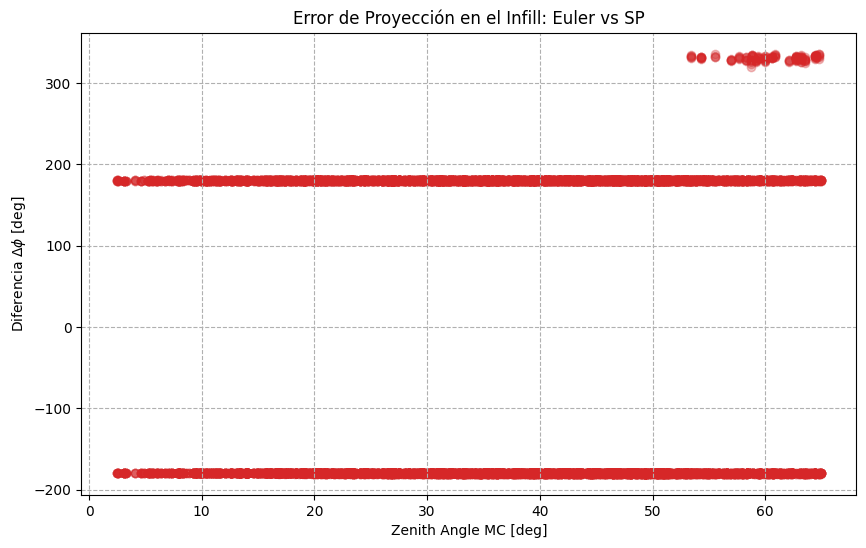

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Separar los datos
df_infill = df[df['sdId'] < 90000].copy()
df_ring = df[(df['sdId'] >= 90000) & (df['sdId'] < 100000)].copy()

# 2. Calcular el error de la geometría estándar (SP) en el Infill
df_infill['delta_phi_deg'] = (df_infill['phi_plane_euler'] - df_infill['phi_plane_sp']) * 180 / np.pi

# 3. Plotear
plt.figure(figsize=(10, 6))
plt.scatter(df_infill['theta_MC'], df_infill['delta_phi_deg'], alpha=0.1, color='tab:red')
plt.title("Error de Proyección en el Infill: Euler vs SP")
plt.xlabel("Zenith Angle MC [deg]")
plt.ylabel("Diferencia $\Delta\phi$ [deg]")
plt.grid(True, ls='--')
plt.show()

In [4]:
# Esta es la parte MÁS IMPORTANTE:
# Asegúrate de que estás corriendo este Jupyter Lab desde una terminal
# donde ANTES hiciste: source /ruta/a/auger/offline/this-auger-offline.sh

AugerOfflineRoot = os.environ.get("AUGEROFFLINEROOT")
if AugerOfflineRoot is None:
    raise EnvironmentError(
        "AUGEROFFLINEROOT no definido. "
        "Reinicia Jupyter Lab desde una terminal donde hayas "
        "hecho: "
        " 'aug_set_version offline 4.0.1-icrc23-prod1-root6' "   
        " 'source /srv/software/amd64/ubuntu/24.04/auger/offline/4.0.1-icrc23-prod1-root6/bin/this-auger-offline.sh'."
    )

print(f"AUGEROFFLINEROOT encontrado en: {AugerOfflineRoot}")

# Cargar las librerías necesarias
print("Cargando librerías de Auger Offline...")
libs_to_load = ["libRecEventKG.so"]
for lib in libs_to_load:
    lib_path = os.path.join(AugerOfflineRoot, "lib", lib)
    if not os.path.exists(lib_path):
        raise FileNotFoundError(f"No se encontró la librería: {lib_path}")
    
    # Usamos gSystem.Load que es más robusto en PyROOT
    status = ROOT.gSystem.Load(lib_path)
    if status < 0:
        raise ImportError(f"Error cargando la librería: {lib_path}")

print("Librerías cargadas correctamente. ¡Listo para trabajar! 🚀")

AUGEROFFLINEROOT encontrado en: /srv/software/amd64/ubuntu/24.04/auger/offline/4.0.1-icrc23-prod1-root6
Cargando librerías de Auger Offline...
Librerías cargadas correctamente. ¡Listo para trabajar! 🚀


In [6]:
import ROOT
import os

# Usamos el archivo de test que ya conocemos
test_file = "/srv/data/Malargue/icrc2025/test7/IdealMC_CORSIKA/MdSdInfill_CORSIKA78010_FLUKA/QGSIII01/17.5_18.0/helium/QGSIII01_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run010.root"
f = ROOT.RecEventFile(test_file)
event = ROOT.RecEvent()
f.SetBuffers(event)
f.ReadNextEvent()

sEvent = event.GetSDEvent()

# --- 1. Determinar método correcto para cantidad de estaciones ---
n_stations = 0
if hasattr(sEvent, "GetNumberOfStations"):
    n_stations = sEvent.GetNumberOfStations()
elif hasattr(sEvent, "GetNStations"):
    n_stations = sEvent.GetNStations()
else:
    n_stations = sEvent.GetStationVector().size()

print(f"✅ Estaciones encontradas en el evento: {n_stations}")

# --- 2. Buscar datos de simulación ---
found_sim = False
for i in range(n_stations):
    st = sEvent.GetStation(i)
    if not st: continue
    
    sdId = st.GetId()
    if sEvent.HasSimStation(sdId):
        simSt = sEvent.GetSimStationById(sdId)
        found_sim = True
        print(f"\n📡 --- Diagnóstico Estación Simulada {sdId} ---")
        
        # Listamos todos los métodos que contengan "Signal" para ver si el nombre cambió
        print("🔍 Métodos disponibles en simSt que contienen 'Signal':")
        metodos = [m for m in dir(simSt) if "Signal" in m]
        for m in metodos:
            try:
                valor = getattr(simSt, m)()
                print(f"   -> {m}(): {valor}")
            except:
                print(f"   -> {m}(): (Requiere argumentos)")
        
        # Prueba específica de componentes
        print("\n🧪 Componentes Clave:")
        if hasattr(simSt, "GetTotalSignal"): print(f"   Total Signal: {simSt.GetTotalSignal()}")
        if hasattr(simSt, "GetMuonSignal"): print(f"   Muon Signal: {simSt.GetMuonSignal()}")
        
        # Si todo da cero, revisamos si la señal está en 'VEM'
        if hasattr(simSt, "GetTotalSignalVEM"): print(f"   Total VEM: {simSt.GetTotalSignalVEM()}")
        
        break

if not found_sim:
    print("❌ No se encontró ninguna SimStation en este evento.")

✅ Estaciones encontradas en el evento: 25

📡 --- Diagnóstico Estación Simulada 4001 ---
🔍 Métodos disponibles en simSt que contienen 'Signal':
   -> GetElectronSignal(): 0.0
   -> GetMuonSignal(): 0.0
   -> GetPhotonSignal(): 0.0

🧪 Componentes Clave:
   Muon Signal: 0.0


In [7]:
import ROOT

# (Asumimos que ya tenés cargado el evento y la simSt del diagnóstico anterior)
# Si no, corré el bloque anterior hasta definir 'simSt'

print(f"🔍 Buscando señales no nulas en la SimStation...")
print("-" * 50)

# Listamos todos los atributos y métodos del objeto
for attr in dir(simSt):
    # Buscamos solo los que parecen ser de extracción de datos (Get...)
    if attr.startswith("Get"):
        try:
            # Intentamos ejecutar el método
            metodo = getattr(simSt, attr)
            valor = metodo()
            
            # Si devuelve un número y no es cero, lo atrapamos
            if isinstance(valor, (int, float)) and valor != 0:
                print(f"✨ ¡ENCONTRADO!: {attr}() = {valor}")
        except:
            # Algunos métodos requieren argumentos o no son llamables, los saltamos
            pass

🔍 Buscando señales no nulas en la SimStation...
--------------------------------------------------
✨ ¡ENCONTRADO!: GetId() = 4001
✨ ¡ENCONTRADO!: GetMaxNParticles() = 4294967295
✨ ¡ENCONTRADO!: GetNumberOfElectrons() = 877
✨ ¡ENCONTRADO!: GetNumberOfMuons() = 75
✨ ¡ENCONTRADO!: GetNumberOfPhotons() = 14427
✨ ¡ENCONTRADO!: GetPlaneFrontTimeNSecond() = 345678036.5489555
✨ ¡ENCONTRADO!: GetPlaneFrontTimeSecond() = 1104122008.0
✨ ¡ENCONTRADO!: GetThinParticleCount() = 124091
✨ ¡ENCONTRADO!: GetThinning() = 1.0
✨ ¡ENCONTRADO!: GetTotalParticleCount() = 15386
✨ ¡ENCONTRADO!: GetUsedWeight() = 1.0
